In [16]:
from spin_lattices import KagomeLattice, SpinLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from fast_boolean_analysis import (
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    FourierSeries,
    fourier_expand,
)
from lattice_boolean_analysis import (
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
    LBFFromSpinSystem,
)
from loguru import logger

from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse
import sys

from parity import popcount

ground_state_cache_dir = Path("groundstates")


def total_hamming_weight(series: FourierSeries, terms: int) -> int:
    return popcount(np.asarray(np.argpartition(series.coeffs, -terms)[-terms:])).sum()


def get_score_column(df: pd.DataFrame, scorer: str) -> list:
    return [
        row["series"].truncate(keep_largest_n(row["terms"])).prediction_score(scorer=scorer)
        for _, row in tqdm(df.iterrows())
    ]

logger.remove()
logger.add(Path("boolean-analysis-complexity.log", level="DEBUG"))


2

In [17]:
%matplotlib inline

In [18]:
lattices = {height: KagomeLattice(width=2, height=height) for height in [2, 3, 4]}
height_to_use_symmetries = {2: False, 3: False, 4: True}


In [19]:
%matplotlib widget

In [20]:
J2s = [0.0, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
signal_kinds = [SignSignalKind(), AmplitudeMedianBinSignalKind()]

In [21]:
all_series: dict[tuple[int, float, str], FourierSeries] = {}
for (height, J2, signal_kind) in product(lattices, J2s, signal_kinds):
    lattice = lattices[height]
    use_symmetries = height_to_use_symmetries[height]
    system=HeisenbergJ1J2(
                lattice=lattice,
                J1=1,
                J2=J2,
                use_symmetries=use_symmetries,
                spin_inversion=1 if use_symmetries else None,
                ground_state_cache_dir=ground_state_cache_dir,
                show_progress=True,
    )
    system.get_eigenstates(1)
    series = fourier_expand(LBFFromSpinSystem(system=system, eigenstate=0, kind=signal_kind))

    all_series[height, J2, signal_kind.name] = series


number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 924
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-False-None-1.pickle
Ground state energy is -23.2969224448
number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 924
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-False-None-1.pickle
Ground state energy is -23.2969224448
number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 924
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.3-False-None-1.pickle
Ground state energy is -21.2511068943
number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 924
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.3-False-None-1.pickle
Ground state energy is -21.2511068943
number_s

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Ground state energy is -20.1659260823
number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 924
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.7-False-None-1.pickle
Ground state energy is -20.1659260823
number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 924
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.8-False-None-1.pickle
Ground state energy is -20.4365959529
number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 924
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.8-False-None-1.pickle
Ground state energy is -20.4365959529
number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 924
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.9-False-None-1.pickle
Ground s

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


number_spins=18
Symmetry group contains 0 elements
Hilbert space dimension is 48620
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-False-None-1.pickle
Ground state energy is -34.6339591099
number_spins=18
Symmetry group contains 0 elements
Hilbert space dimension is 48620
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.3-False-None-1.pickle
Ground state energy is -31.5823856157
number_spins=18
Symmetry group contains 0 elements
Hilbert space dimension is 48620
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.3-False-None-1.pickle
Ground state energy is -31.5823856157
number_spins=18
Symmetry group contains 0 elements
Hilbert space dimension is 48620
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.5-False-None-1.pickle
Ground state energy is -29.6279366224


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
Ground state energy is -46.1341392314
Finding basis_state_info
Finding corresp_repr_indices
Finding coeffs


/vol/tcm10/ischurov/frustrations-eda/heisenberg_hamiltonians.py:204: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs[self.canonical_basis.states] = (


number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
Ground state energy is -46.1341392314
Finding basis_state_info
Finding corresp_repr_indices
Finding coeffs
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.3-True-1-1.pickle
Ground state energy is -42.0743085888
Finding basis_state_info
Finding corresp_repr_indices
Finding coeffs
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.3-True-1-1.pickle
Ground state energy is -42.0743085888
Finding basis_state_info
Finding corresp_repr_indices
Finding coeffs
number_spins=24
Symmetry group contains 16 elements


In [41]:
scorers = ["sign_overlap", "accuracy", "f1"]
max_terms = 4000

rows = []

for (height, J2, signal_kind), series in all_series.items():
    print(f"{height}, {J2}, {signal_kind}")
    success, how_many_terms, prediction = series.how_many_terms_to_achieve_score(
        0.95, scorer="sign_overlap", max_terms=max_terms, orbitwise=False
    )
    scores = {
        scorer: series.truncate(
            keep_largest_n(how_many_terms)
        ).prediction_score(scorer=scorer, prediction=prediction)[0]
        for scorer in scorers
    }
    rows.append(
        {
            "height": height,
            "J2": J2,
            "signal_kind": signal_kind,
            "series": series,
            "success": success,
            "terms": how_many_terms,
        }
        | scores
    )


2, 0.0, sign
2, 0.0, amplitude_median_bin
2, 0.3, sign
2, 0.3, amplitude_median_bin
2, 0.5, sign
2, 0.5, amplitude_median_bin
2, 0.6, sign
2, 0.6, amplitude_median_bin
2, 0.7, sign
2, 0.7, amplitude_median_bin
2, 0.8, sign
2, 0.8, amplitude_median_bin
2, 0.9, sign
2, 0.9, amplitude_median_bin
2, 1.0, sign
2, 1.0, amplitude_median_bin
3, 0.0, sign
3, 0.0, amplitude_median_bin
3, 0.3, sign
3, 0.3, amplitude_median_bin
3, 0.5, sign
3, 0.5, amplitude_median_bin
3, 0.6, sign
3, 0.6, amplitude_median_bin
3, 0.7, sign
3, 0.7, amplitude_median_bin
3, 0.8, sign
3, 0.8, amplitude_median_bin
3, 0.9, sign
3, 0.9, amplitude_median_bin
3, 1.0, sign
3, 1.0, amplitude_median_bin
4, 0.0, sign
4, 0.0, amplitude_median_bin
4, 0.3, sign
4, 0.3, amplitude_median_bin
4, 0.5, sign
4, 0.5, amplitude_median_bin
4, 0.6, sign
4, 0.6, amplitude_median_bin
4, 0.7, sign
4, 0.7, amplitude_median_bin
4, 0.8, sign
4, 0.8, amplitude_median_bin
4, 0.9, sign
4, 0.9, amplitude_median_bin
4, 1.0, sign
4, 1.0, amplitude_med

In [42]:
series_df = (
    pd.DataFrame(rows)
    .assign(
        hamming_weight=lambda df: df.apply(
            lambda row: total_hamming_weight(row["series"], int(row["terms"]) if not np.isnan(row["terms"]) else max_terms), axis=1
        ),
        number_spins=lambda df: df["series"].apply(lambda a: a.signal.number_spins),
    )
    .assign(
        mean_hw=lambda df: df["hamming_weight"] / df["terms"],
    )
    .set_index(["height", "J2", "signal_kind"])
)


In [43]:
series_df

series  \
height J2  signal_kind                                                               
2      0.0 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.3 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.5 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.6 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.7 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.8 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.9 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       1.0 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
3      0.0 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.3 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.5 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.6 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.7 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.8 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.9 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       1.0 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
4      0.0 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.3 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.5 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.6 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.7 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.8 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
       0.9 sign                  <fast_boolean_analysis.FourierSeries object at...   
           amplitude_median_bin  <

In [44]:
%matplotlib inline

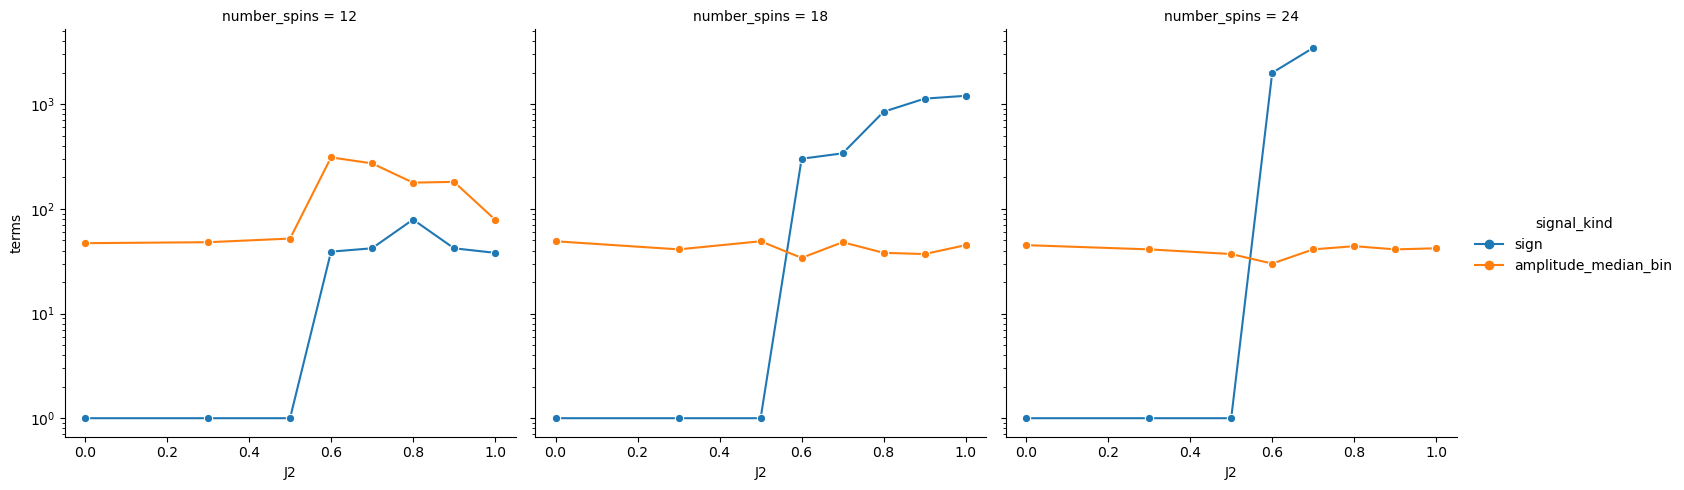

In [46]:
sns.relplot(
    series_df,
    x="J2",
    y="terms",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    # markers=True,
    style="signal_kind",
    dashes=False,
    markers=["o", "o"],
    # make y axis independent
    # facet_kws=dict(sharey=False),
).set(yscale="log")


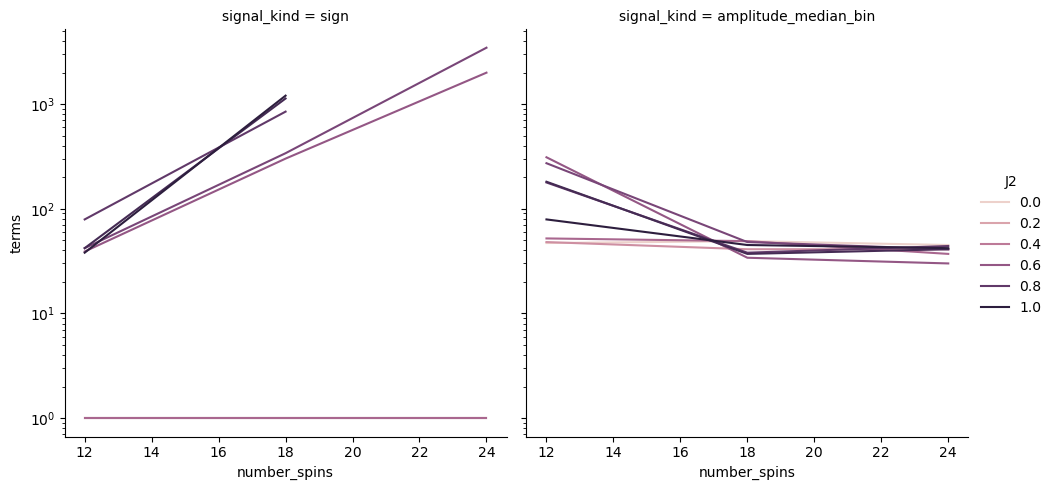

In [50]:
sns.relplot(
    series_df.reset_index(),
    # .assign(J2=lambda df: df["J2"].astype(str)),
    x="number_spins",
    y="terms",
    col="signal_kind",
    hue="J2",
    kind="line",
    markers=True,
).set(yscale="log")


In [51]:
def plot_subsets(subsets, lat: SpinLattice):
    fig, axes = plt.subplots(1, len(subsets), figsize=(len(subsets) * 3, 3), squeeze=False)
    for ax, subset in zip(axes[0], subsets):
        lat.plot(spins=subset, ax=ax)
        ax.axis("off")
    return fig


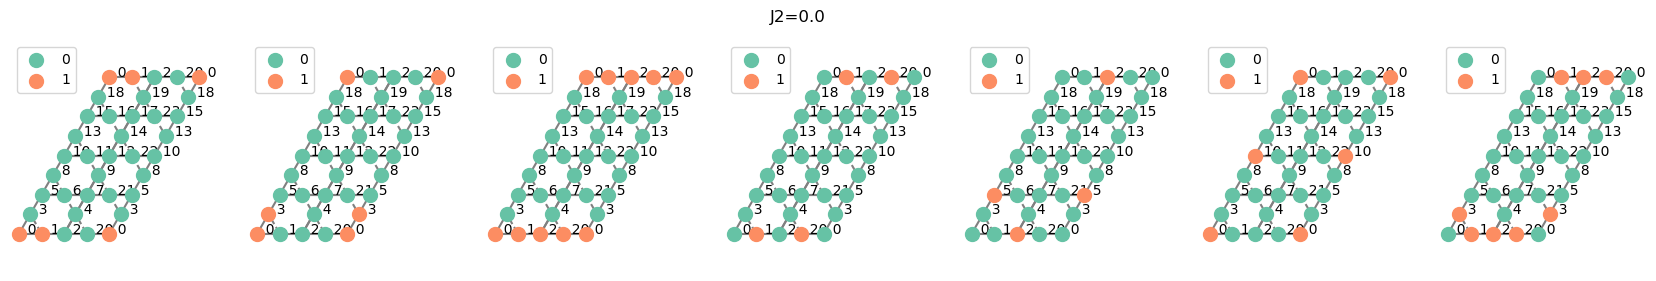

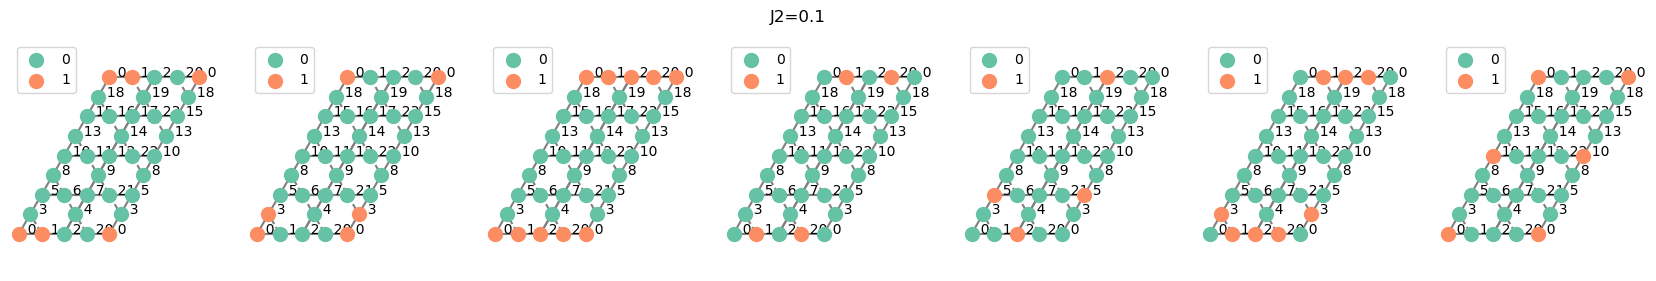

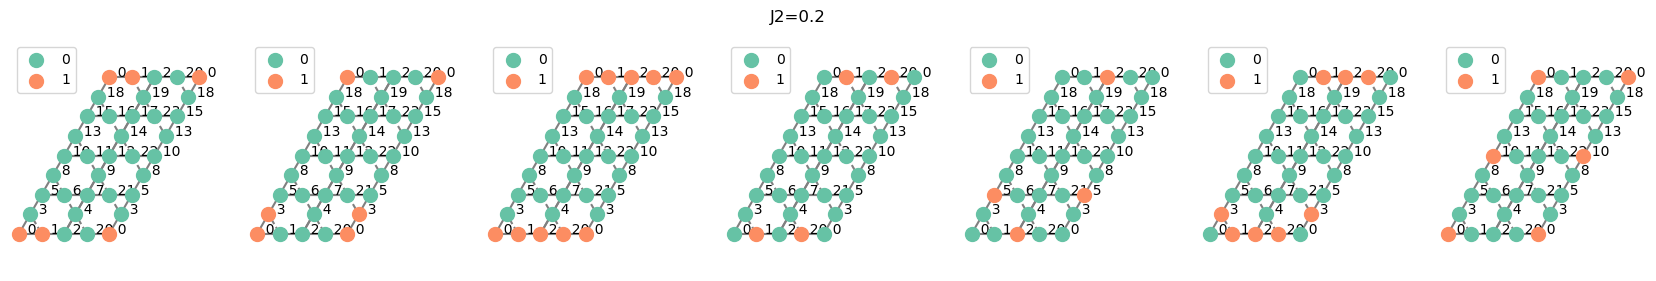

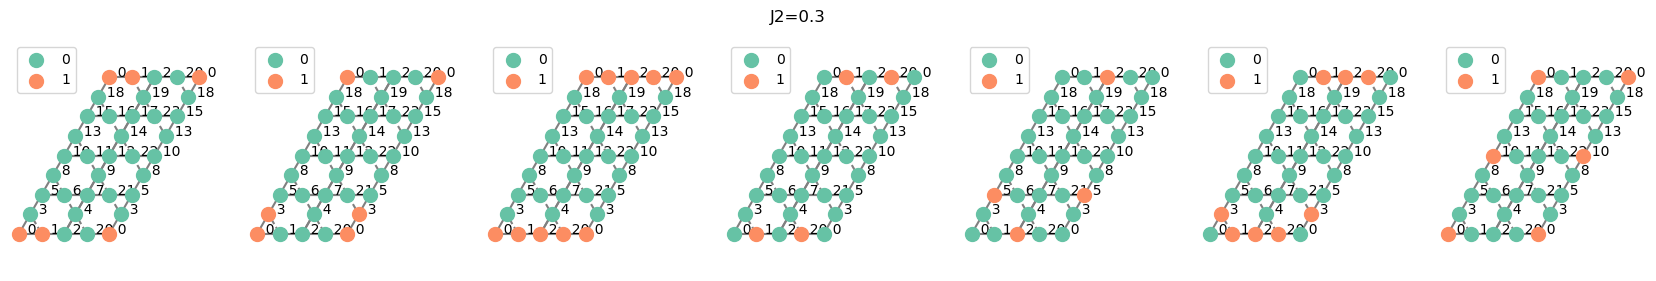

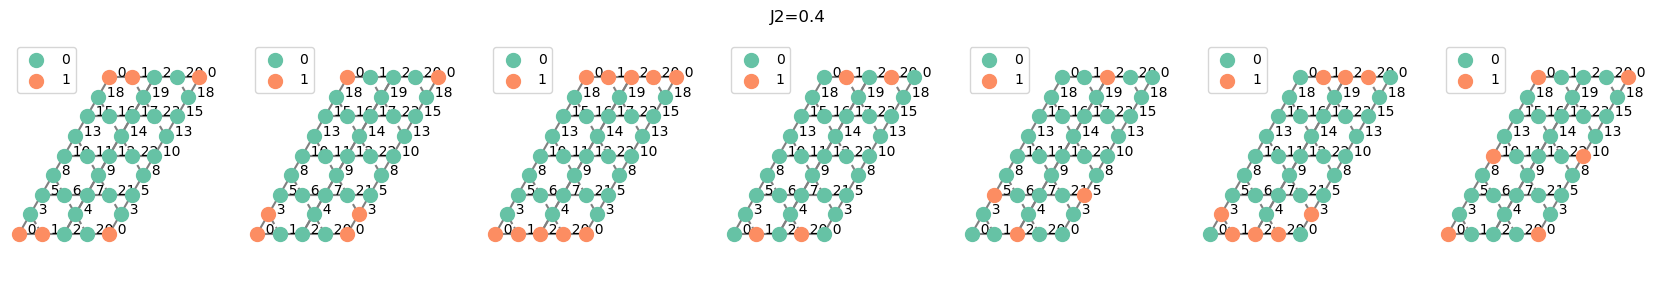

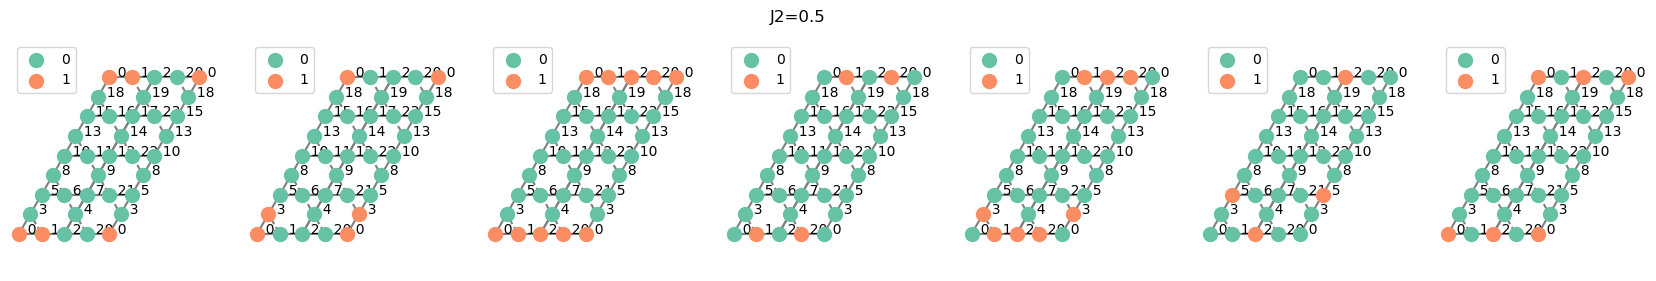

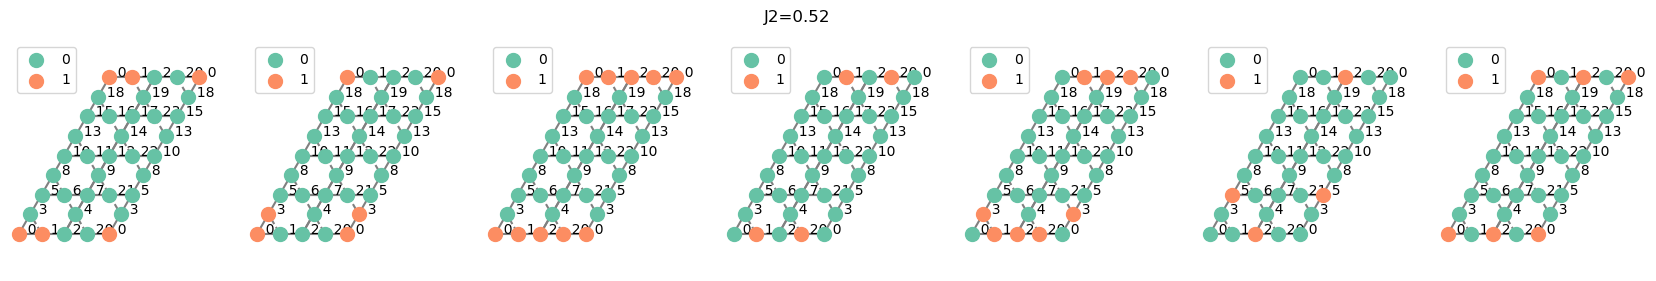

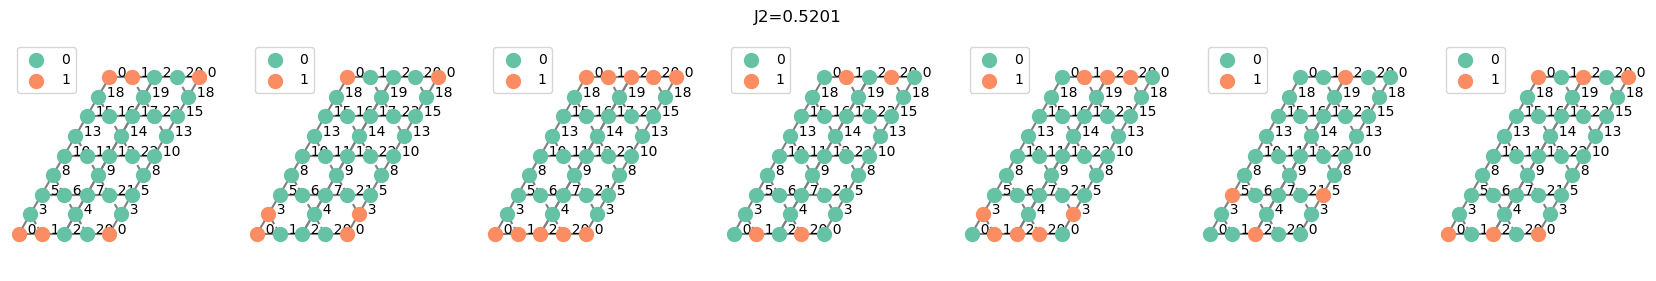

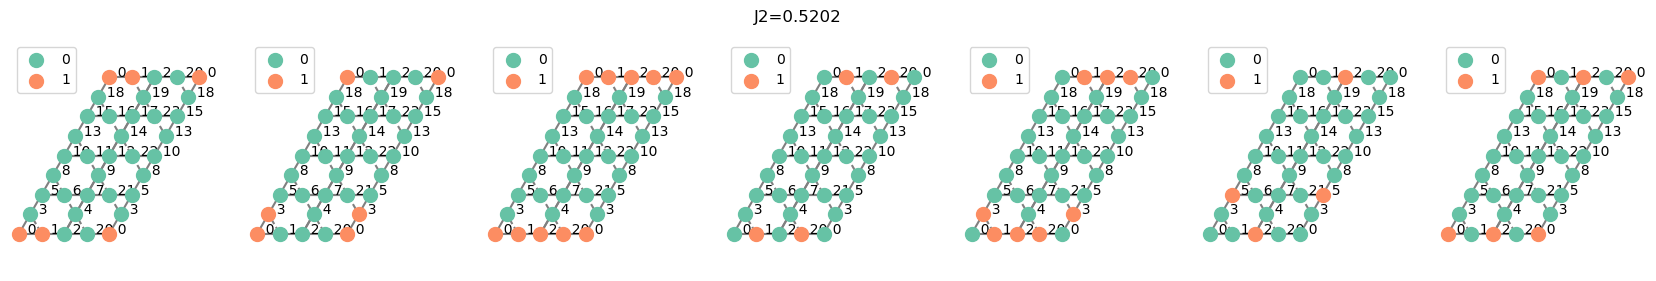

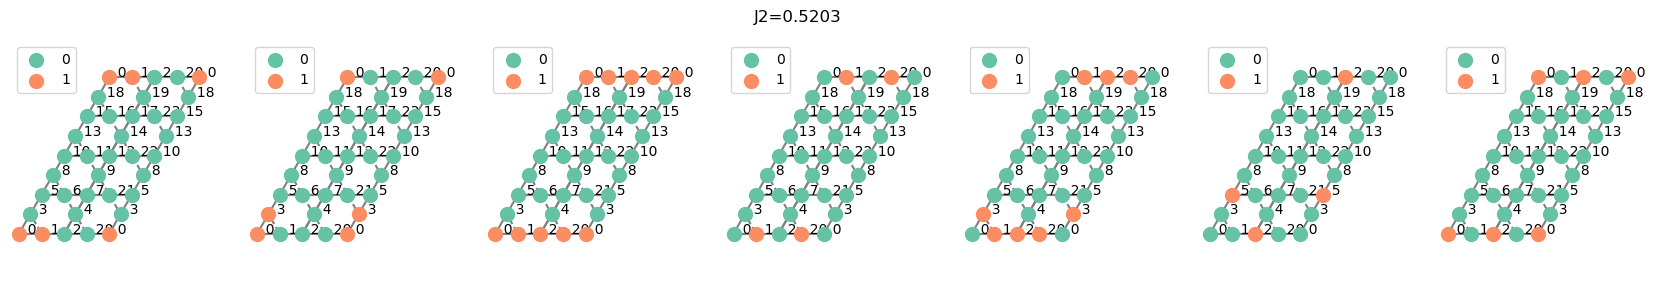

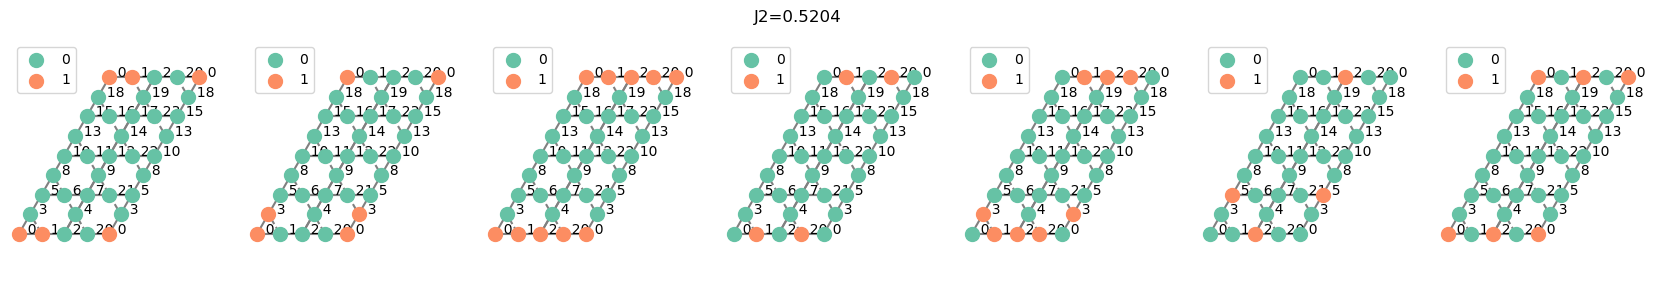

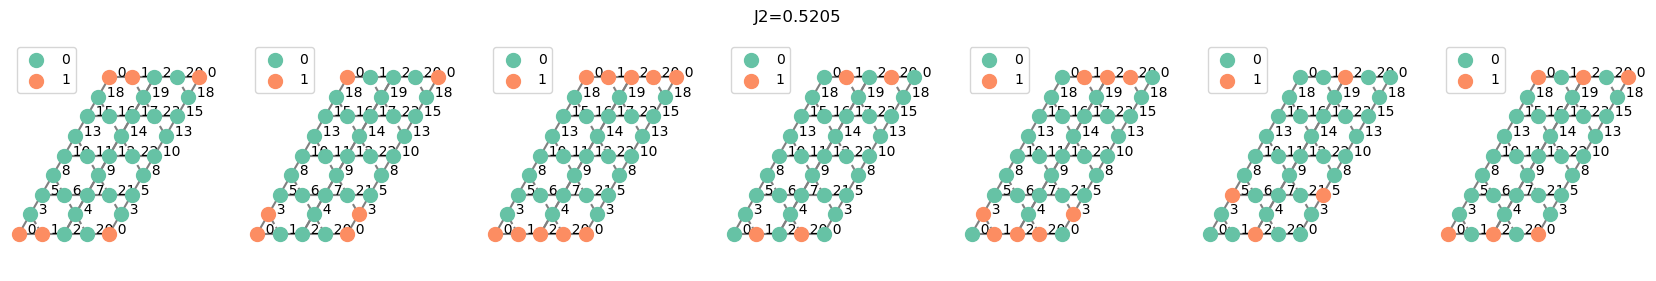

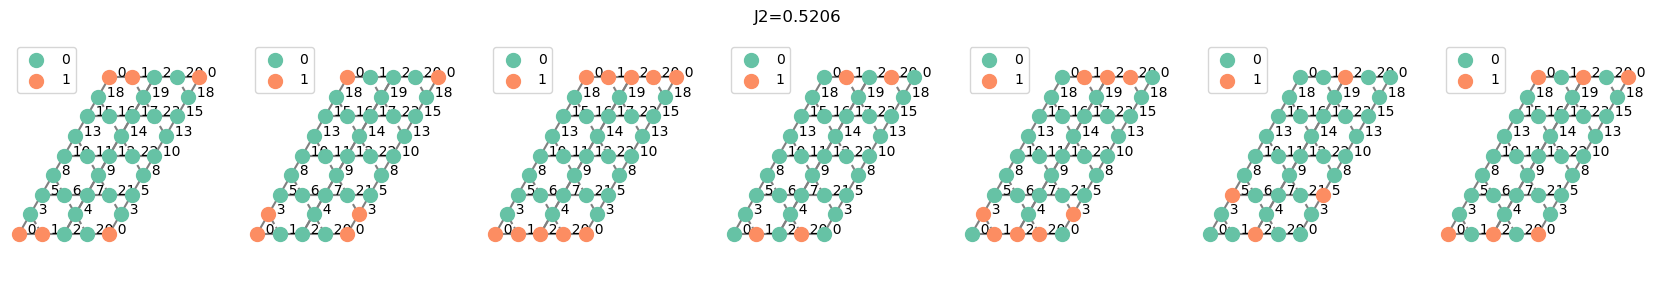

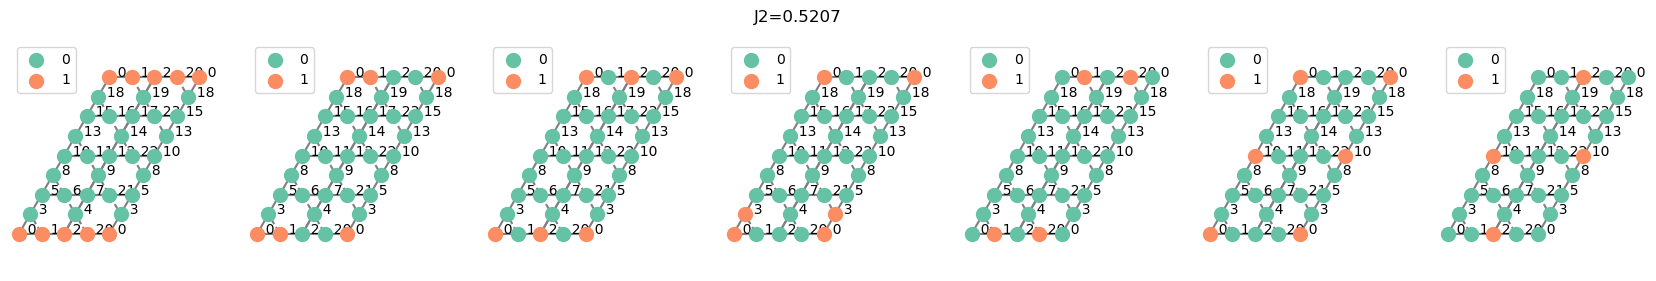

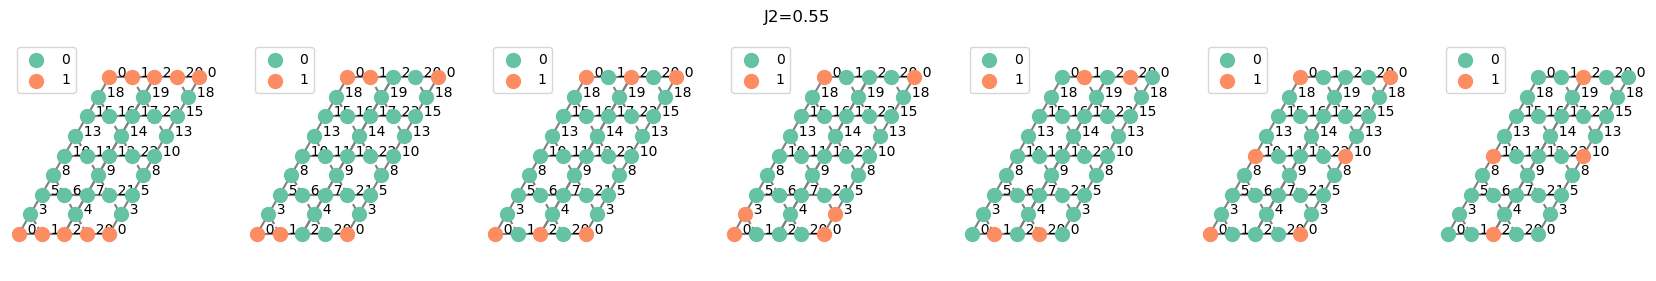

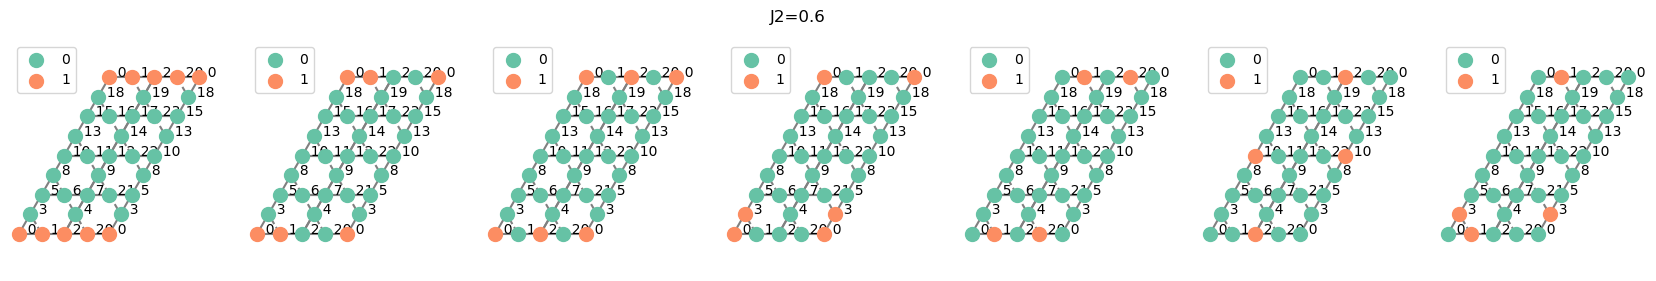

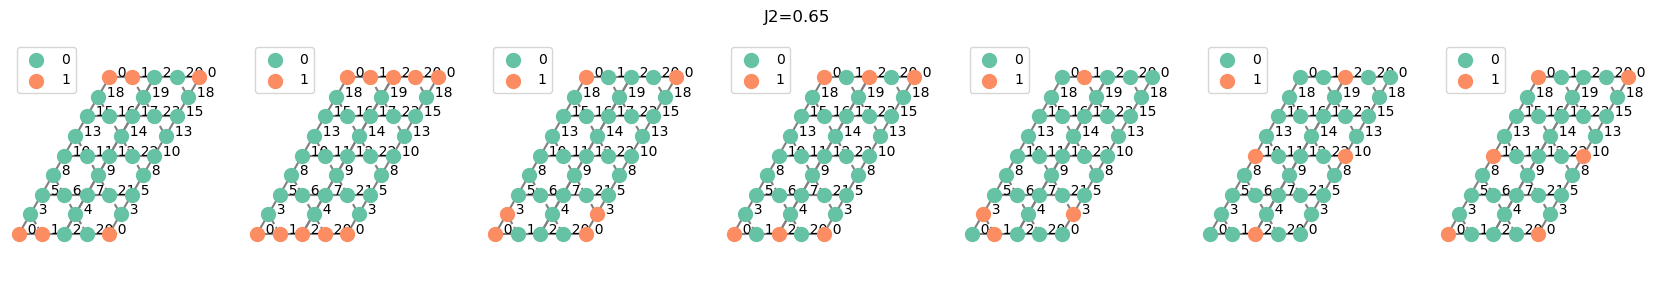

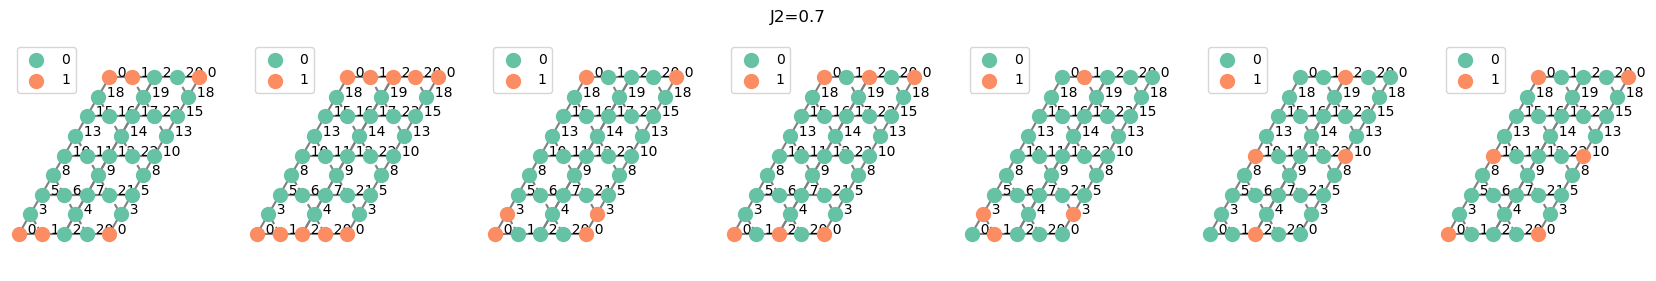

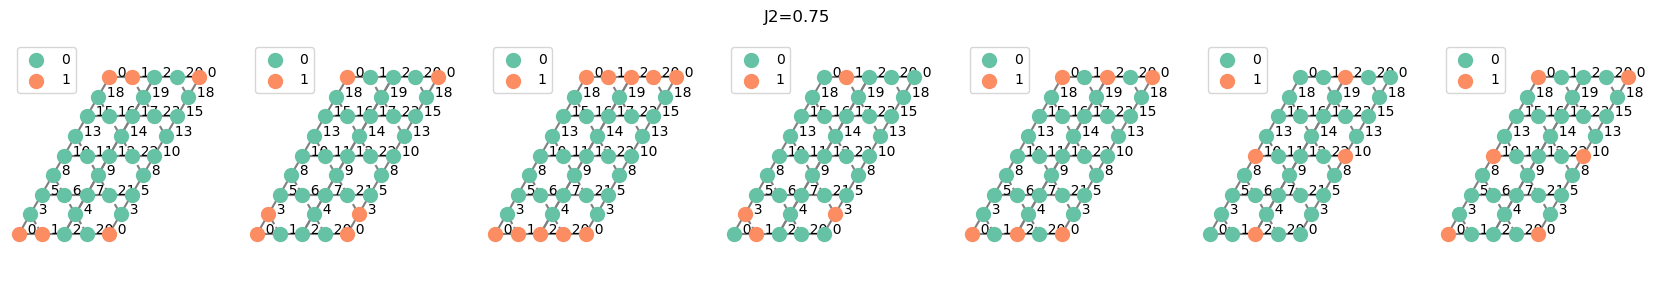

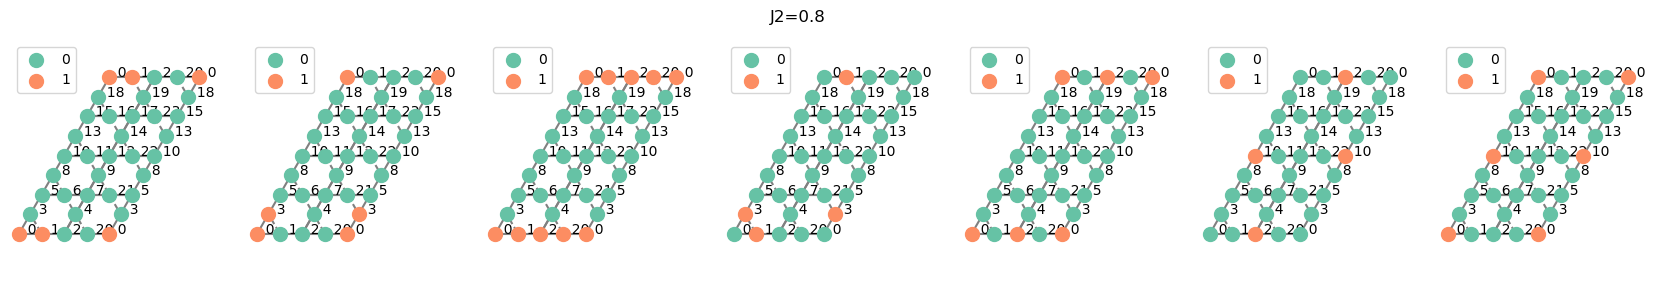

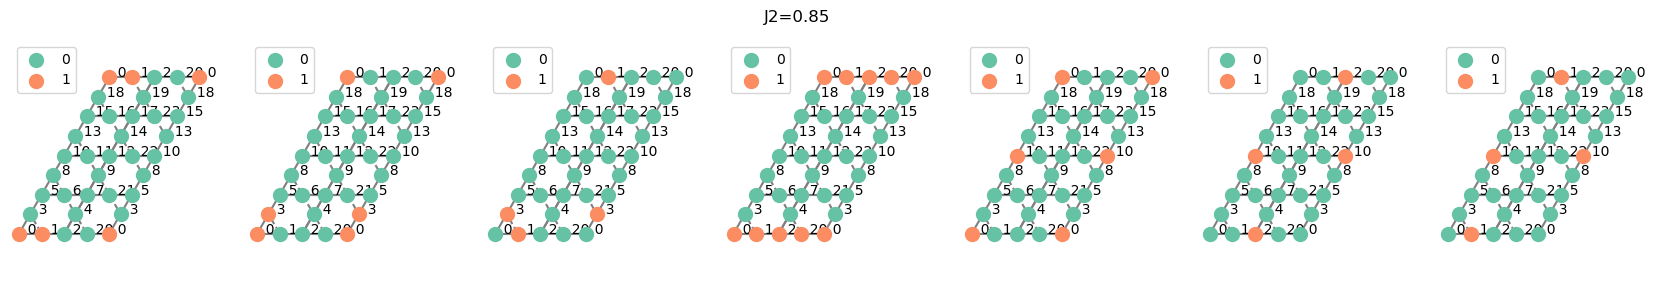

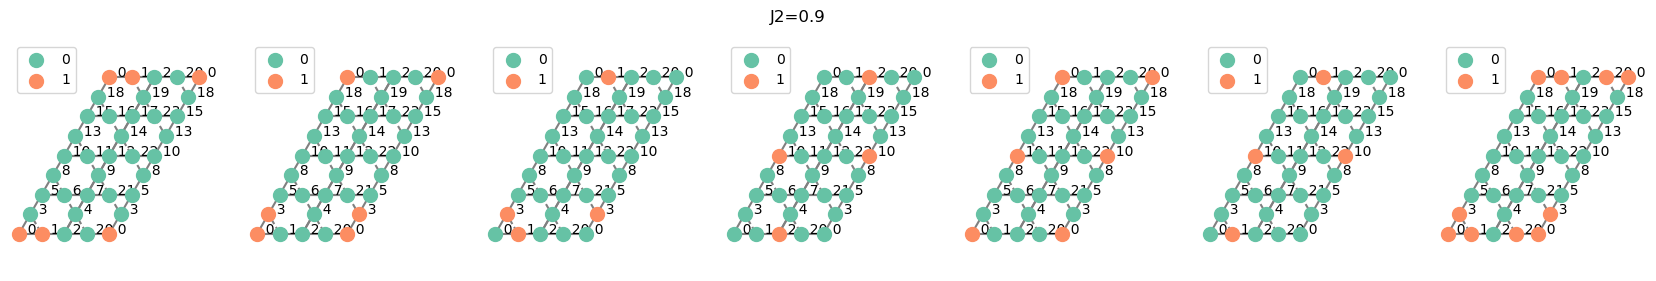

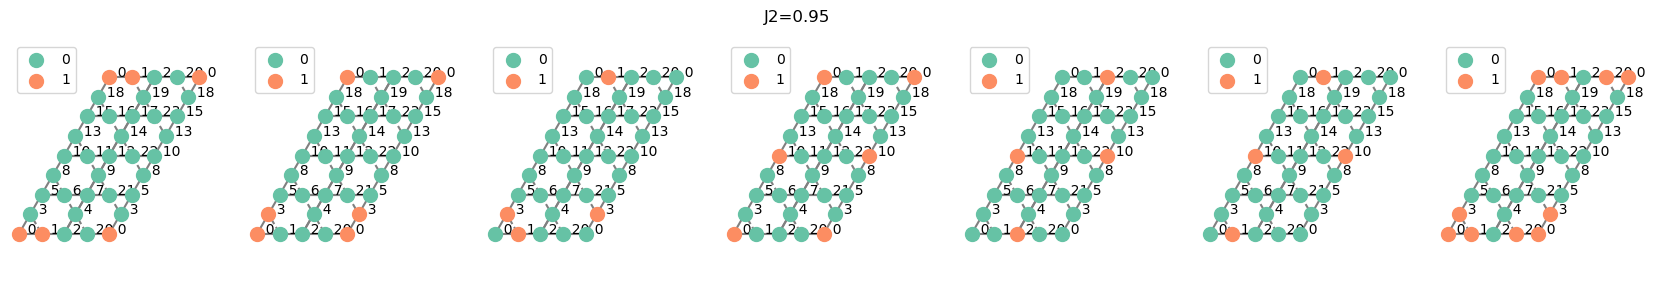

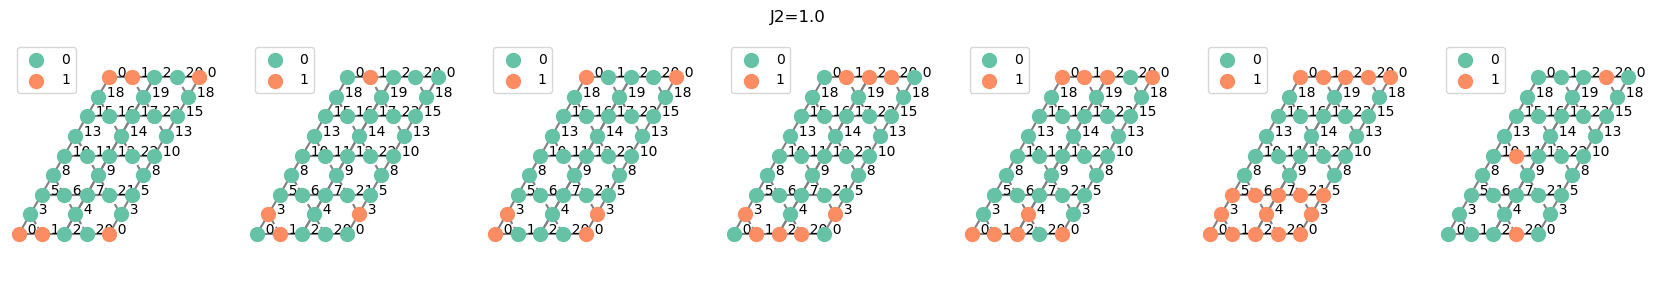

In [79]:
height = 4
signal = "amplitude_median_bin"
max_subsets = 7
# signal = "sign"
for J2, subsets in (
    series_df.sort_index(level="J2")
    .xs((height, signal), level=("height", "signal_kind"))
    .assign(
        subsets=lambda df: [
            list(row["analyzer"].learner.get_coeffs_ser().iloc[: row["terms"]].index)
            for _, row in df.iterrows()
        ],
    )["subsets"]
    .items()
):
    plot_subsets(subsets[:max_subsets], KagomeLattice(width=2, height=height))
    plt.suptitle(f"J2={J2}")
    plt.show()


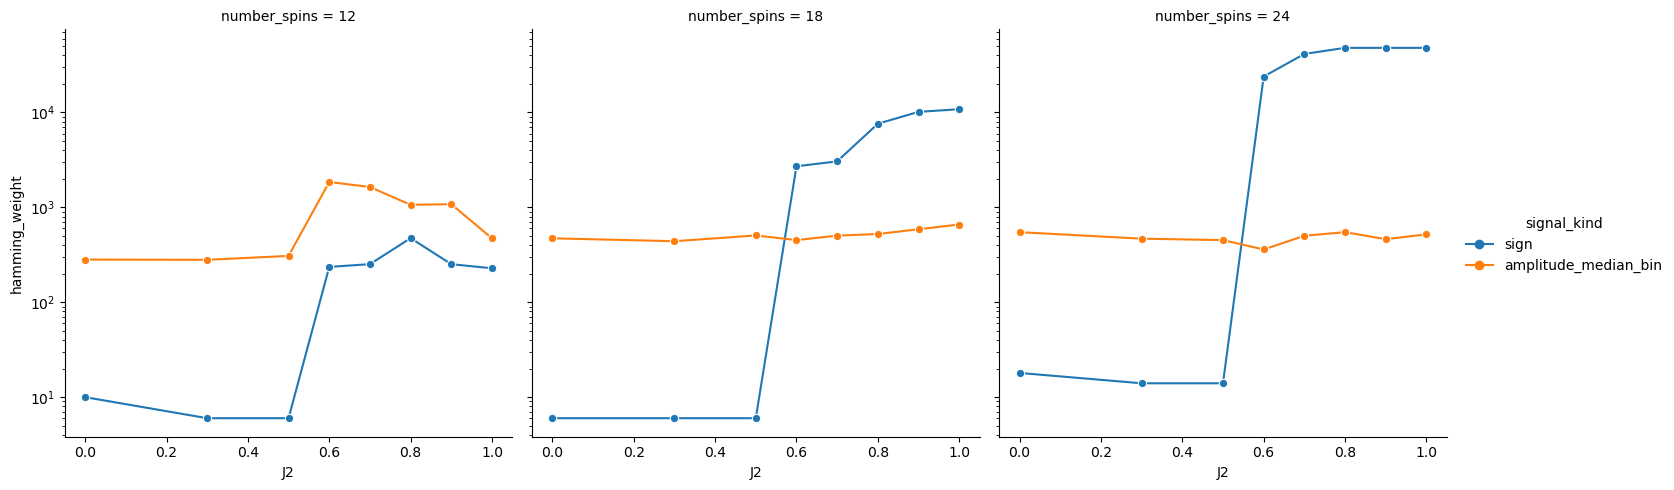

In [52]:
sns.relplot(
    series_df,
    x="J2",
    y="hamming_weight",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    style="signal_kind",
    dashes=False,
    facet_kws=dict(sharex=True),
    markers=["o", "o"],
).set(yscale="log")


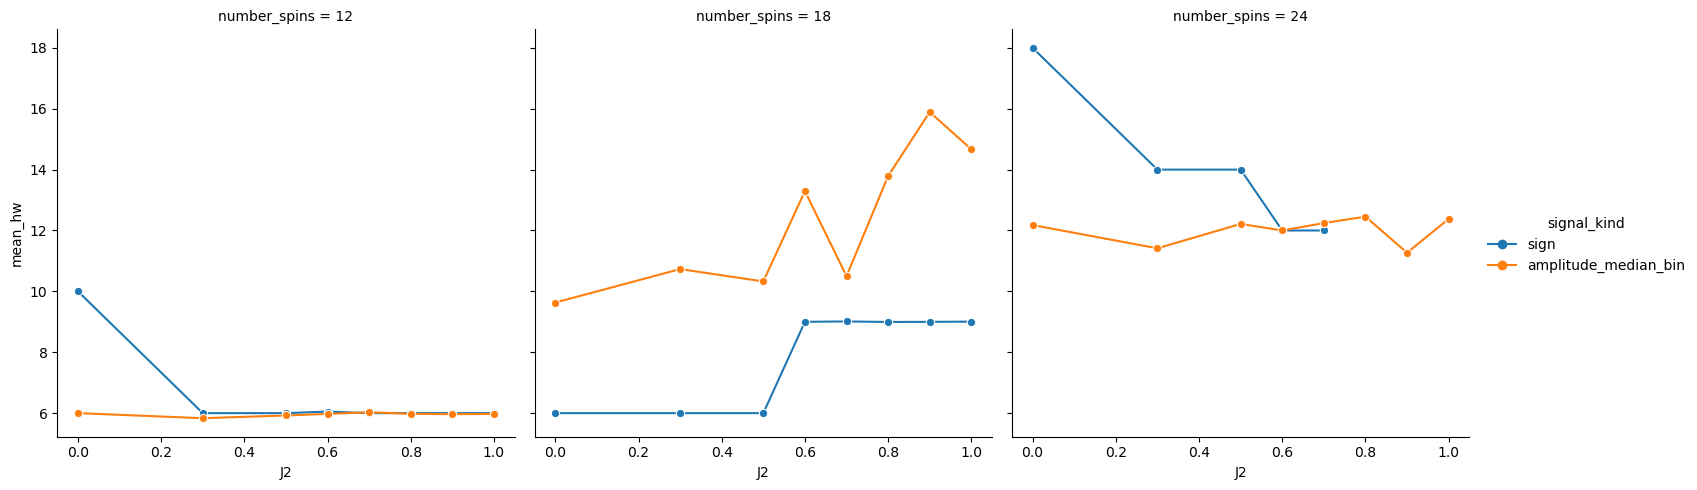

In [53]:
sns.relplot(
    series_df,
    x="J2",
    y="mean_hw",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


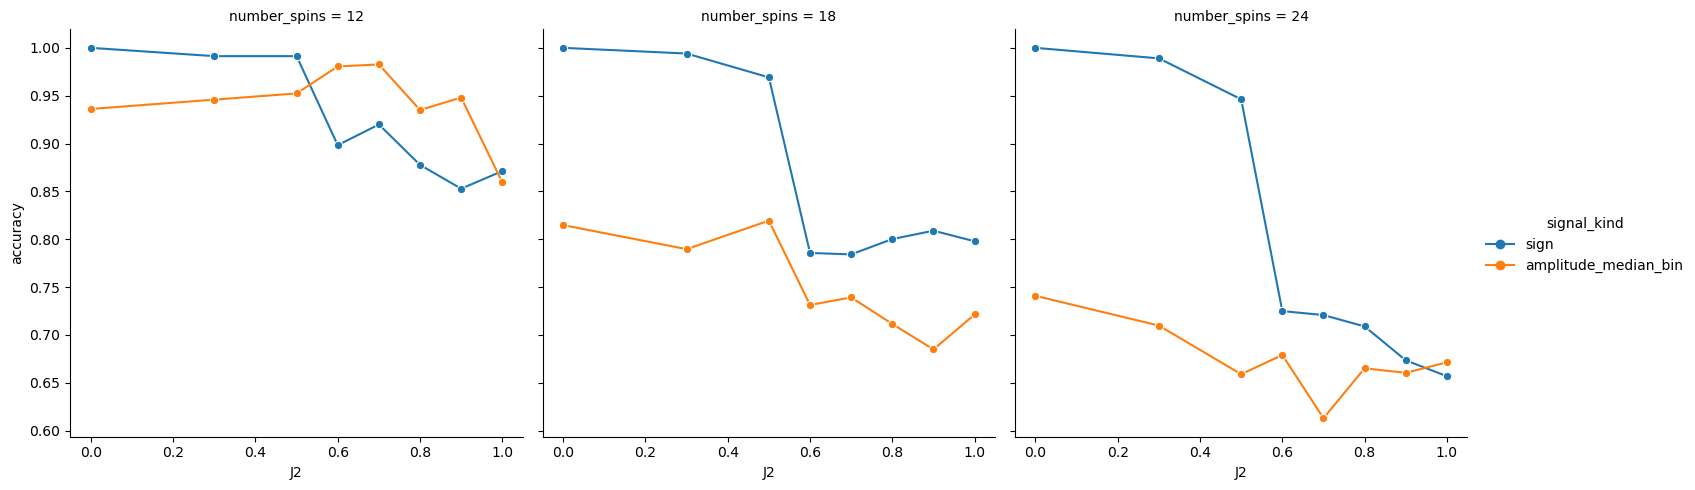

In [54]:
sns.relplot(
    series_df,
    x="J2",
    y="accuracy",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


In [55]:
complexity_ratio_df = (
    series_df.unstack(level="signal_kind")["hamming_weight"]
    .assign(ratio=lambda df: df["sign"] / df["amplitude_median_bin"])
    .reset_index()
)


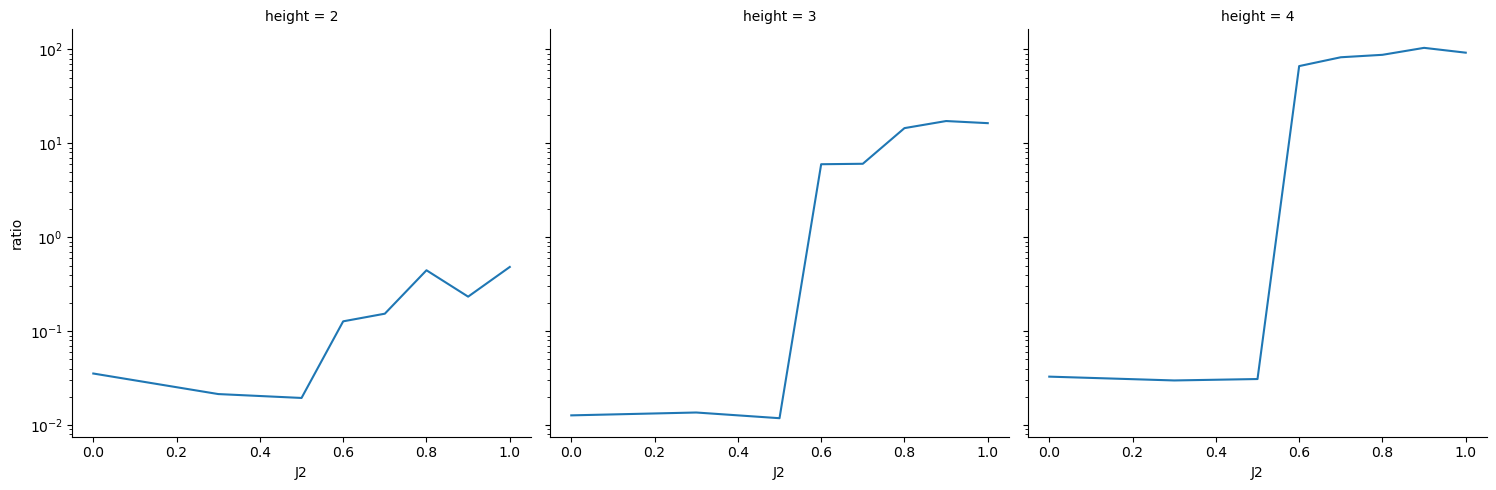

In [56]:
sns.relplot(complexity_ratio_df, x="J2", y="ratio", col="height", kind="line").set(yscale="log")


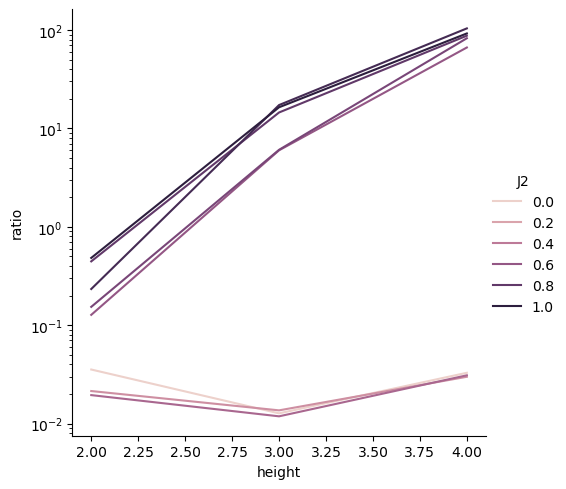

In [57]:
sns.relplot(
    complexity_ratio_df,
    x="height",
    y="ratio",
    hue="J2",
    kind="line",
).set(yscale="log")
